#Preamble

This mini-project involves working through all the steps of a problem, whereas prior assignments asked you to just implement core functions. We will give you a dataset, but you will also have the opportunity to manipulate the data in ways that you find beneficial to the overall project and to explain why and how those manipulations mattered. This will be in addition to building the model from scratch, developing the training loop, and implementing testing. The code will be accompanied by a report written into the notebook.

This project will have you working with attention mechanism, in a new type of system for question-answering. This will provide you with experience working with attention mechanisms while not directly working with transformers.

This assignment is not autograded. You can modify any code cells as long as you achieve the requirements of each graded component.

# Introduction

Memory networks learn to access external memory stores (a database or, in the case of this assignment, a dictionary). Key-Value Memory Networks specifically assume that the external memory store is organized as a dictionary with keys and values. In theory memory networks are useful when one wants a neural network to be able to know a lot of information but we don't want to try to encode that information directly into the parameters of the network. This means information can be changed in the external memory database without retraining the neural network.

Given a question, e.g., "Where was Alexander Hamilton born?", a key-value memory network learns an embedding such that the question has a high cosine similarity to a particular key in the external dictionary. Because there are many keys that need to be matched against, key-value memory networks implement an attention-scoring mechanism to select a key. Because attention is a probabilistic score, the key-value memory network retrieves a sum of embeddings weighted according to the attention score. This weighted embedding is then compared to values using a second attention-scoring mechanism. The value with the highest cosine similarity can then be retrieved and returned as the answer.

Memory networks were an important part of the evolution of question-answering systems that have been eclipsed by transformers. However, the attention mechanism in a key-value memory network is very similar to the self-attention inside a transformer, so implementing a key-value memory network is a really great way to experiment and learn about self-attention without the added complexity of transformers.

Key-value memory networks are also closely related to retieval-based generation networks, except we will be retrieving facts from a dictionary instead of via the internet. However, the embedding of retrieved data will be similar.

Key-value memory networks are described in this [paper](https://arxiv.org/abs/1606.03126). It is recommended that you read the paper, but we will also walk through the steps you will need to complete.

# Some imports



You may add imports as necessary.

In [ ]:
import torch
import torch.nn as nn
from torch import optim
import torch.nn.functional as F
import re
import os
import json
import random
import numpy as np
import pickle
from tqdm import tqdm
import nltk
from nltk.corpus import stopwords
import matplotlib.pyplot as plt

In [ ]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'
device

'cuda'

Unidecode is useful for getting rid of issues that arise from unicode. This should not be used if we care about unicode, but for the purposes of an instructional exercise, it eliminates a lot of edge cases that come up with unicode.

In [ ]:
!pip install unidecode

In [ ]:
import unidecode

If you need to have a reduced vocabulary, you can create an unknown "unk" token and add it to the vocabulary. Make sure the token index in the vocabulary and `UNK_ID` match.

In [ ]:
UNK = 'unk'
UNK_ID = '0'

# Some utilities

You may edit these as necessary.

Stem words

In [ ]:
# Stemming the text
def simple_stemmer(text):
    ps=nltk.porter.PorterStemmer()
    text= [ps.stem(word) for word in text]
    return text

Simple tokenizer that only keeps letters and numbers.

In [ ]:
def tokenize(line):
    line = re.sub(r'[^a-zA-Z0-9]', ' ', unidecode.unidecode(line)) # remove punctuation
    line = line.lower().split()  # lower case
    return line

A standard vocabulary object class

In [ ]:
class Vocab:
    def __init__(self, name = 'vocab'):
        self.name = name
        self._word2index = {}
        self._word2count = {}
        self._index2word = {}
        self._n_words = 0

    def get_words(self):
      return list(self._word2count.keys())

    def num_words(self):
      return self._n_words

    def word2index(self, word):
      return self._word2index[word]

    def index2word(self, word):
      return self._index2word[word]

    def word2count(self, word):
      return self._word2count[word]

    def add_sentence(self, sentence):
        for word in tokenize(sentence):
            self.add_word(word)

    def add_word(self, word):
        if word not in self._word2index:
            self._word2index[word] = self._n_words
            self._word2count[word] = 1
            self._index2word[self._n_words] = word
            self._n_words += 1
        else:
            self._word2count[word] += 1

Make a bag of words frmo a sentence, given a vocabulary. Can return a bag of word counts or a a bag of word presences.

In [ ]:
def multihot(s, vocab, preserve_counts = False):
  tokens = np.array([vocab.word2index(t) for t in tokenize(s)])
  mhot = np.zeros((tokens.size, vocab.num_words()))
  mhot[np.arange(tokens.size), tokens] = 1
  if preserve_counts:
    return mhot.sum(0)
  else:
    return mhot.sum(0) >= 1


If you have a reduced vocabulary, use this to replace out-of-vocab words. If you use this, you may want to merge it with `multihot` above to avoid tokenizing twice.

In [ ]:
def unkit(s, vocab):
  return ' '.join(list(map(lambda x: UNK if x not in vocab._word2index else x, tokenize(s))))

# Part A: Download and Process Data (0 points)

This dataset contains the information in tables that are commonly used in Wikipedia biography pages. Each person has different rows of information pertaining to their notable accomplishments and details about their life. There are a large number of types of information that can appear as rows in the biography tables, however they are relatively uniform. We call the keys of the rows "relations".

For example [Alexander Hamilton](https://en.wikipedia.org/wiki/Alexander_Hamilton) has information about the President he worked for as Secretary of State, birth date, date of death, parents' names, etc.

The code below will download the dataset and process it to create two things:
- `DB`: a hash table that map titles of biography wikipedia articles to table information. The table information is represented as a nested hash table containing relations as keys, and associated values. For example, `DB['alexander hamilton'] = {'party': 'federalist',
 'spouse': 'elizabeth schuyler', ...}`
- `VOCAB`: A vocabulary object that maps words to tokens and vice versa.

In [ ]:
!git clone https://github.com/rlebret/wikipedia-biography-dataset.git

Cloning into 'wikipedia-biography-dataset'...
remote: Enumerating objects: 93, done.
remote: Total 93 (delta 0), reused 0 (delta 0), pack-reused 93 (from 1)
Receiving objects: 100% (93/93), 338.68 MiB | 45.51 MiB/s, done.
Resolving deltas: 100% (43/43), done.


In [ ]:
!cat wikipedia-biography-dataset/wikipedia-biography-dataset.z?? > tmp.zip
!unzip -o tmp.zip
!rm tmp.zip

Archive:  tmp.zip
   creating: wikipedia-biography-dataset/test/
  inflating: wikipedia-biography-dataset/test/test.box  
  inflating: wikipedia-biography-dataset/test/test.id  
  inflating: wikipedia-biography-dataset/test/test.nb  
  inflating: wikipedia-biography-dataset/test/test.sent  
  inflating: wikipedia-biography-dataset/test/test.url  
  inflating: wikipedia-biography-dataset/test/test.contributors  
  inflating: wikipedia-biography-dataset/test/test.title  
   creating: wikipedia-biography-dataset/train/
  inflating: wikipedia-biography-dataset/train/train.box  
  inflating: wikipedia-biography-dataset/train/train.id  
  inflating: wikipedia-biography-dataset/train/train.nb  
  inflating: wikipedia-biography-dataset/train/train.sent  
  inflating: wikipedia-biography-dataset/train/train.url  
  inflating: wikipedia-biography-dataset/train/train.contributors  
  inflating: wikipedia-biography-dataset/train/train.title  
   creating: wikipedia-biography-dataset/valid/
  infla

Get all the wikipedia titles.

In [ ]:
train_titles = []
with open("wikipedia-biography-dataset/train/train.title", "r") as file:
  for line in file:
    train_titles.append(line.rstrip())

Boxes contain all the information, with each line corresponding to a title in `titles`.

In [ ]:
train_boxes = []
with open("wikipedia-biography-dataset/train/train.box", "r") as file:
  for line in file:
    train_boxes.append(line.rstrip())

This will make the DB object, a dictionary of dictionaries for each wikipedia title, which is more or less the same as names. This function only keeps politicians (containing the "office" key term) and strips out information about images. It can be improved in many ways.

In [ ]:
# Make a dictionary of dictionaries
def make_db(titles, boxes):
  db = {} # The DB
  # Iterate through titles
  for i in tqdm(range(len(titles))):
    box = boxes[i] # Grab the corresponding box information
    d  = {} # Inner dictionary
    # Build a dict for the ith entry
    # grab each key:value pair
    for pair in re.findall(r'([a-zA-Z_]+)[0-9]*\:([\w\d]+)', box):
      key, value = pair
      # Do a bit of cleaning
      key = key.strip()
      value = value.strip()
      # If the key contains the word image, we probably don't want to keep it
      if 'image' not in key:
        # The regex maintains underscores, strip those off
        if key[-1] == '_':
          key = key[:-1]
        # Make a new entry in inner dictionary if we don't have one
        if key not in d:
          d[key] = value
        # Keys with compound values are split up, which is annoying, so put them back together
        else:
          d[key] += ' ' + value
    # If it has an office key, keep it.
    if 'office' in d:
      db[titles[i]] = d
  return db

Build the vocab from the DB. Convert the whole thing into a string, tokenize it, and feed the surviving words into the vocab.

In [ ]:
def make_vocab(DB):
  # Make the vocab object
  vocab = Vocab()
  # Tokenize the data by converting the entire DB into a string
  tokens = tokenize(str(DB))
  # Iterate through all the tokens (tqdm provides a progress bar)
  for t in tqdm(tokens):
    vocab.add_word(t)
  return vocab

If you want to discard rare words, this will rebuild the vocab. This is just an example.

In [ ]:
def reduce_vocab(vocab, min_word_occurrence = 2):
  # make a new vocab
  vocab2 = Vocab("top")
  # Add the UNK token
  vocab2.add_word(UNK)
  # Iterate through vocabulary
  for w in list(vocab._word2count.keys()):
    count = vocab._word2count[w]
    idx = vocab._word2index[w]
    # If the word count passes threshold, add it to the new vocabulary object
    if count >= min_word_occurrence:
      vocab2.add_word(w)
      vocab2._word2count[w] = count
  # Return the new vocabulary object
  return vocab2

Make the DB

In [ ]:
DB = make_db(train_titles, train_boxes)

100%|██████████| 582659/582659 [00:46<00:00, 12628.52it/s]


Make the VOCAB

In [ ]:
VOCAB = make_vocab(DB)
print(VOCAB.num_words())

100%|██████████| 2997937/2997937 [00:01<00:00, 2524919.69it/s]

96093


In [ ]:
# Filtering out words that appear less than 5 times
VOCAB = reduce_vocab(VOCAB, 5)
print(VOCAB.num_words())

29390


## Save Processed Data

You may find it useful to save the processed dataset to your Google Drive.

It is recommended that you save the file to your Google Drive. To mount your Google Drive, open the file icon on the left side of the screen to get to the option). To save the file in your Google Drive use the path `'drive/MyDrive/filename'`.)

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
with open("drive/MyDrive/data", "wb") as f:
  pickle.dump(DB, f, protocol=None, fix_imports=True, buffer_callback=None)

In [ ]:
with open('drive/MyDrive/vocab', 'wb') as f:
    pickle.dump(VOCAB, f, protocol=None, fix_imports=True, buffer_callback=None)

## Load processed data

If you have saved the processed data in your Google Drive, you can re-load it with these commands.

In [ ]:
with open("drive/MyDrive/vocab", "rb") as f:
  VOCAB = pickle.load(f)

In [ ]:
with open("drive/MyDrive/data", "rb") as f:
  DB = pickle.load(f)

## Data example

Get to know your data.

In [ ]:
DB["alexander hamilton"]

{'name': 'alexander hamilton',
 'office': '1st united states secretary of the treasury senior officer of the army delegate to the congress of the confederation from new york',
 'president': 'george washington john adams',
 'term_start': 'september 11 1789 december 14 1799 november 3 1788 november 4 1782',
 'term_end': 'january 31 1795 june 15 1800 march 2 1789 june 21 1783',
 'predecessor': 'position established george washington egbert benson seat established',
 'successor': 'oliver wolcott jr james wilkinson seat abolished seat abolished',
 'birth_date': '11 january 1755',
 'birth_place': 'charlestown nevis british west indies',
 'death_date': 'july 12 1804 aged 47 or 49',
 'death_place': 'new york city new york u',
 'party': 'federalist',
 'spouse': 'elizabeth schuyler',
 'children': 'philip angelica alexander james alexander john church william stephen eliza holly phil',
 'alma_mater': 'kings college new york',
 'religion': 'presbyterian episcopalian convert',
 'signature': 'alexan

# Part B: Implement the Key-Value Memory Network (10 points)

This [paper](https://arxiv.org/abs/1606.03126) describes the key-value memory networks in detail, which is also sketched out below.

A key-value memory network takes a natural language question. This question will be converted into a bag-of-words (i.e., a multihot) Call this $x$ and it is a 1D tensor of vocabulary length.

![KVMemNet architecture](https://github.com/markriedl/kvmemnet-assignment/blob/32479dd1e88a9f8dfc72f11ccb8e9e0e1f78905f/kvmemnet-inside.png?raw=true)

The KVMemNet will contain a linear layer (or embedding layer) that will produce a 1D embedding of the question $q=A(x)$.

The KVMemNet will also take in a stack of keys as a tensor of shape `num_keys x vocab_size`. Each row is embedded using the same embedding, $k=A(keys)$, producing a tensor of shape `num_keys x embed_dim`. How this stack of keys is chosen will be discussed below.

The KVMemNet will take in a third input, a stack of values associated with the stack of keys. This will also be of shape `num_values x vocab_size`. Each row is embedded using the same embedding, $v=A(values)$, producing a tensor of shape `num_keys x embed_dim`.

The KVMemNet will also contain a second linear embedding layer, $B$. More on this later.

Once we have `q`, `k`, and `v` embeddings, the next step is to use `q` and `k` to compute attention scores that can be applied against `v`. Think of $A$ as learning how to make questions and the keys that should match against values that have received the same treatment.

The attention scores `p` are computed by taking the inner-product (`torch.inner()`) between `q` and `k`. The result will be a 1D tensor with `num_keys` length. Use softmax so that `p` contains scores between 1.0 and 0.0.

You may be wondering why there isn't a non-linearity such as a sigmoid or ReLU after the linear layer. Softmax is a non-linearity.

Next apply the `p` attention scores against `v` to apply a weight against each value in the stack of values. One should be highly weighted and the rest less weighted. Sum all the weighted values up to create a 1D tensor `o` of feature weights of length `embed_dim`. `p` can be thought of as how much of each value gets selected. Then they all get combined together and the feature weights are proportional to how much each value was attended to. The `torch.matmul()` can do the multiplication and summing in one step.

The KVMemNet forward function should return this tensor of feature weights `o`.

A quick note on `k` and `v`. We can't send the entire set of keys and values in our database through the network's forward function. Instead there should be a selection mechanism that selects just a subset of the database. This subset should contain the best key for the question $x$ to match against, and its corresponding value. We assume that a shallow selection process can narrow down the key-value pairs to a relatively small set, one of which will be best. For example, if the question involves "Alexander Hamilton", we can reasonably guess that the best key-value pair is in the part of the database associated with the named person.

We are not done though. What about our linear layer $B$? Suppose variable `Y` contains our entire set of values in our databse as bags of words. $B$ is going to be used to embed our entire set of database values $y=B(Y)$. $B$ can be thought of as learning how to make all the values look like the feature weights output by the model such that the highest cosine similarity corresponds to the correct value taken from *all* values in the database.

$B$ should live inside the KVMemNet object so that its parameters become trainable, but notice that we do not use $B$ in the KVMemNet's forward function. $B$ will get used to prepare the stack of all values in the database for training. It will bet used in the training loop but outside of the forward function. This is a bit unusual, but necessary to figure out the correct target (the true index of the best value to match against) for training.

The above explantion only implements *single-hop* retrieval. *multi-hop* retrieval allows the results of one retrieval to inform a second (and third and so on) to get the right retrieval. This would be used in the case where the answer cannot be inferred directly from the question in a single retrieval, such as "What was the founding date of the country that Alexander Hamilton was born in?". To implement multi-hop retrieval, the KVMemNet will have additional linear layers $R_1...R_n$. Each $R_{i}$ will do a linear transform on `q` then attention will score and retrieve values as feature weights `o`. This will be sent to the next $R_{i+1}$ and so on until the hops are complete. This final `o` will be returned.

For this assignment is is sufficient to only do *single-hop* retrieval.

The above explanation does not include consideration of batching. You may want to add a batch dimension as the first dimension and input a batch as a set of questions, a set of stacks of keys, and a set of stacks of values. To do this, functions like `.inner()`, `.mm()`, and`.matmul()` will not work. Instead use `.bmm()` which handles batching correctly. You will probably need to do some `.squeeze()` and `.unsqueeze()` operations to make sure your tensors are the correct shapes.

Instead of bag-of-words, one may also consider first converting each question, key, and value into a general set of embeddings such as [GLoVe](https://nlp.stanford.edu/projects/glove/). To do this one will need to consider how to combine words--convert each word into an embedding vector and then add the vectors together (or maybe average them).

**Complete the key-value memory net code**

In [ ]:
class KVMemNet(nn.Module):
  def __init__(self, vocab_size, embed_dim):
    super(KVMemNet, self).__init__()
    self.vocab_size = vocab_size
    self.embed_dim = embed_dim
    ### YOUR CODE HERE
    self.A = nn.Linear(vocab_size, embed_dim, bias=False)
    self.B = nn.Linear(vocab_size, embed_dim, bias=False)

  def forward(self, x, keys, values):
    output = None
    ### YOUR CODE BELOW
    q = self.A(x)
    k = self.A(keys)
    v = self.B(values)

    scores = torch.inner(q, k)
    p = F.softmax(scores, dim=-1)

    output = p @ v
    ### YOUR CODE ABOVE
    return output


# Synthetic Data Set

This is a synthetic dataset. One way to test a model during development is to take a small piece of data and show that you can overfit a model. If you can't overfit an easily learned chunk of data, then you probably have something wrong in your code. In this case I have provided a small chunk of synthetic data that should be easy to learn.

- The vocabulary is 20 word: 5 names, 5 relations, 5 question-words, 5 values
 - First 5 elements of the vocab are names (for example index 0 might be "Hamilton").
 - Second 5 elements of the vocab are relations (for example, "born", "died", "occupation").
 - Third 5 elements are random words that might be part of a query (for example, "When was").
 - Final 5 elements of the vocab are possible values (for example, "1757")
- A "question" is a name (5, 1), relation (5, 1), some words (5, 1), and no values
- The keys will all have the same name (5, 5) where each row is idential, relations (5, 5), no words, no values
- Values will have no names, no relations, no words, and value vocab words

In [ ]:
# Turn on a different relation on each row
relations = torch.zeros(5, 5)
relations.fill_diagonal_(1)

# training data
train_data = {}
for i in range(5):
  # Name associated with questions, keys, values
  train_data[i] = (torch.cat([F.one_hot(torch.arange(0, 5))[i].repeat(5, 1),
                         relations,
                         torch.randint(0, 2, (5, 5)).float(),
                         torch.zeros(5, 5)], dim=1),
              torch.cat([F.one_hot(torch.arange(0, 5))[i].repeat(5, 1),
                         relations,
                         torch.zeros(5, 5),
                         torch.zeros(5, 5)], dim=1),
              torch.cat([torch.zeros(5, 5),
                         torch.zeros(5, 5),
                         torch.zeros(5, 5),
                         torch.randint(0, 2, (5, 5)).float()], dim=1))
  Y = torch.cat([v[2] for v in list(train_data.values())], dim=0).to('cuda')

In [ ]:
# Display synthetic question, keys, values, and target matrix dimensions
print("Questions shape:", train_data[0][0].shape)
print("Keys shape:", train_data[0][1].shape)
print("Values shape:", train_data[0][2].shape)
print("Y shape:", Y.shape)

Questions shape: torch.Size([5, 20])
Keys shape: torch.Size([5, 20])
Values shape: torch.Size([5, 20])
Y shape: torch.Size([25, 20])


# Part C: Train on Synthetic Data (5 points)

The following describes the steps to set up a training loop, including the training of the $B$ layer.

![The KVMemNet being used in the training loop](https://github.com/markriedl/kvmemnet-assignment/blob/main/kvmemnet-outside.png?raw=true)

- Create a model with the given vocabulary size and an embedding size that is equal to or smaller.
- Loop through `N` epochs:
 - There are five names, loop through each name.
   - Get a stack of questions, stack of keys, and stack of values from `DB_synth`.
   - Loop through the relations. There is relation on each row of the keys and values.
     - Get a single question, the `i`-th row in the questions pulled from `DB_synth` above.
     - Compute the target: this is the `name*5 + i` element in `Y`.
     - Run the singular question, stack of keys, and stack of values through the model and produce an output, which is a tensor of feature weights.
     - Run all of `Y` through `model.B()` to get an embedded stack of values.
     - Take the softmax of the inner product between the embedded stack of values from `Y` and the feature weight generated by the model.
     - Compute the loss with `nn.CrossEntropyLoss`.
     - Call `.backward()` on the loss.

In addition to printing the loss (after every question or after every name in `DB_synth`) you can also print the target and the argmax of the softmax result to see if they match. Over time you should see the target and the argmax in agreement. For the purposes of this part of the project it is sufficient to test on the training set.

Don't forget to move the model and the tensor to the GPU.

You may want to speed up training by implementing batching. To do this, the model `forward()` needs to take tensors with an extra batching dimension as the first dimension. However, `.inner()`, `.mm()`, and `.matmul()` will not work properly. You will need to use `.bmm()` instead, which understands the first dimension is for batching. You will likely find that you need to perform some `.squeeze()` and `.unsqueeze()` operations. You can try batch-size of one, or take entire chunks (or even all synthetic data as a single, large batch). Try it different ways.

Try training on the synthetic data first.

You may make as many cells as necessary. Save your notebook outputs that plot loss and show it reducing.

**Write code blocks below that create the `KVMemNet`**

In [ ]:
# Set up your KVMemNet, move it to the GPU, setup up optimizer (e.g., Adam), and criterion.
model = KVMemNet(vocab_size = 20, embed_dim = 32).to(device)
optimizer = optim.Adam(model.parameters(), lr = 0.003)
criterion = nn.CrossEntropyLoss()

**Write and run a training testing loop. Show that your training loop loss converges with a plot**

To plot a loss curve, compute the mean loss per epoch and save it in a list:
```
x_axis.append(epoch_number)
y_axis.append(mean_epoch_loss_for_this_epoch)
plt.plot(x_axis, y_axis)
plt.show()
```

Epoch number 0, mean epoch loss for this epoch  3.1124
Epoch number 100, mean epoch loss for this epoch  0.4920
Epoch number 200, mean epoch loss for this epoch  0.4864
Epoch number 300, mean epoch loss for this epoch  0.4857
Epoch number 400, mean epoch loss for this epoch  0.4855
Epoch number 500, mean epoch loss for this epoch  0.4855
Epoch number 600, mean epoch loss for this epoch  0.4855
Epoch number 700, mean epoch loss for this epoch  0.4855
Epoch number 800, mean epoch loss for this epoch  0.4855
Epoch number 900, mean epoch loss for this epoch  0.4855


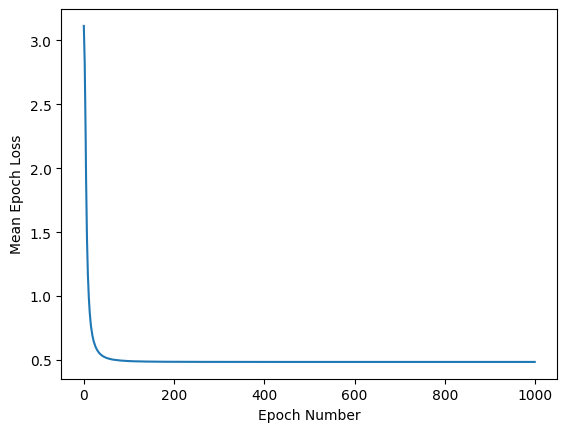

In [ ]:
# Write your training loop here
x_axis, y_axis = [], []
N_EPOCHS = 1000

for epoch_number in range(N_EPOCHS):
  epoch_losses = []
  pairs = [(name, i) for name in range(5) for i in range(5)]
  random.shuffle(pairs)

  for name, i in pairs:
    questions, keys, values = train_data[name]
    questions, keys, values = questions.to(device), keys.to(device), values.to(device)
    question = questions[i]
    target = torch.tensor(name * 5 + i).to(device)

    optimizer.zero_grad()
    output = model(question, keys, values)
    Y_embedded = model.B(Y)
    logits = torch.inner(Y_embedded, output)
    loss = criterion(logits.unsqueeze(0), target.unsqueeze(0))
    loss.backward()
    optimizer.step()
    epoch_losses.append(loss.item())

  mean_epoch_loss_for_this_epoch = sum(epoch_losses) / len(epoch_losses)
  x_axis.append(epoch_number)
  y_axis.append(mean_epoch_loss_for_this_epoch)

  if epoch_number % 100 == 0:
    print(f"Epoch number {epoch_number}, mean epoch loss for this epoch {mean_epoch_loss_for_this_epoch: .4f}")

plt.plot(x_axis, y_axis)
plt.xlabel("Epoch Number")
plt.ylabel("Mean Epoch Loss")
plt.show()

In [ ]:
# Accuracy check of the trained model for each question
correct = 0
total = 0
with torch.no_grad():
  for name in range(5):
    questions, keys, values = train_data[name]
    questions, keys, values = questions.to(device), keys.to(device), values.to(device)
    for i in range(5):
      question = questions[i]
      target = name * 5 + i
      output = model(question, keys, values)
      logits = torch.inner(model.B(Y), output)
      pred = logits.argmax().item()
      correct += int(pred == target)
      total +=1
  print(f"Accuracy: {correct}/{total} = {correct/total:.2%}")

Accuracy: 17/25 = 68.00%


In [ ]:
# Checking each target value of Y is unique
unique_rows = torch.unique(Y, dim = 0)
print(f"Y has {Y.shape[0]} rows, but only {unique_rows.shape[0]} unique rows")

Y has 25 rows, but only 17 unique rows


# Part D: Training on the Full Data (10 points)

To train on the full data, you are going to need to do some pre-processing of the data.

First, there are no "questions". You need to generate questions for each type of relation. There a number of ways to do this. The simplest is to just assume that a question is the name of a person and a relation, e.g., "Alexander Hamilton birth date". Another way would be to create templates for each type of relation. For example the "birth date" relation would have the following template: "When was [name] born?", filling in the [name]. Because there are a lot of different types of relations, you may want to remove the more obscure relations so you need fewer templates and also have a smaller vocabulary. Templates work well if the questions are expected to be almost identical to the templates. You may want to generate multiple templates per relation. Continuing the previous example, a second template would be: "What is the birthdate of [name]?".

If you are feeling more ambitious, you could use GPT-J, GPT-NeoX, GPT-3 or ChatGPT to generate templates. It works decently well and you can get some variety of templates.

The question should contain information about the person and some words that are representative of the relation even if the exact relation words aren't used (the KVMemNet should figure out that "birthdate" and "born" are correlated).

You only put a subset of all key-value pairs into the KVMemNet. You need a technique for sub-selecting from all the key-value pairs in `DB`. You might just need the ones that are directly associated with the person (Alexander Hamilton has 23). You may need to mix in a few key-value pairs from another person's entries in the database to help ensure against accidental overfitting.

The final challenge you will have in the training loop is that there may still be too many unique values in `Y` to encode and create one big tensor. In that case, you can at least use the values that you sent to the KVMemNet, along with as many other randomly selected values as you can fit into the GPU's memory.

Create as many cells below as you need. Save the output of your training and testing functions, reporting loss during training and accuracy during testing. 5 points for a training loop that reduces loss. 5 points for a training function with a correct accuracy computation.

**Create a training dataset and a non-overlapping testing dataset**

If CPU memory becomes a problem you might want to consider a `DataLoader` so that data can be stored on file and pulled up when needed.

In [ ]:
#Count the frequency of each relation in the database
from collections import Counter

relation_counts = Counter()
for person, info in DB.items():
  for key in info:
    if key not in ('name', 'article_title'):
      relation_counts[key] +=1

for relation, count in relation_counts.most_common(20):
  print(f"{relation}: {count}")

office: 40786
term_start: 37144
birth_date: 35272
birth_place: 32183
term_end: 31147
predecessor: 29611
party: 28363
successor: 26128
alma_mater: 16303
death_date: 15339
spouse: 15104
death_place: 12582
nationality: 10791
religion: 10541
children: 8664
occupation: 8247
profession: 8045
residence: 7344
order: 6457
caption: 5124


In [ ]:
# Create your training and test sets here
# 8 common relations with Natural Language question templates.
# Filter DB to these, generate (question, person, relation, answer) examples.
# Split 90/10 by person to avoid leakage in train/ test set.
RELATIONS = ['office', 'birth_date', 'birth_place', 'party', 'death_date', 'spouse', 'alma_mater', 'occupation']

TEMPLATES = {
    'office':      ["What office did {name} hold?", "What position did {name} serve in?"],
    'birth_date':  ["When was {name} born?", "What is the birth date of {name}?"],
    'birth_place': ["Where was {name} born?", "What is the birthplace of {name}?"],
    'party':       ["What political party did {name} belong to?", "Which party was {name} a member of?"],
    'death_date':  ["When did {name} die?", "What is the death date of {name}?"],
    'spouse':      ["Who was {name}'s spouse?", "Who did {name} marry?"],
    'alma_mater':  ["Where did {name} go to school?", "What is the alma mater of {name}?"],
    'occupation':  ["What was {name}'s occupation?", "What did {name} do for work?"],
}

DB_filtered = {
    name: {k: v for k, v in info.items() if k in RELATIONS}
    for name, info in DB.items()
    if any(rel in info for rel in RELATIONS)
}

print(f"Kept {len(DB_filtered)} people out of {len(DB)}")

examples = []
for person_name, info in DB_filtered.items():
    for relation in RELATIONS:
        if relation in info:
            answer_text = info[relation]
            template = random.choice(TEMPLATES[relation])
            question_text = template.format(name=person_name)
            examples.append((question_text, person_name, relation, answer_text))

print(f"Total examples: {len(examples)}")


all_people = list(DB_filtered.keys())
random.shuffle(all_people)

split_idx = int(0.9 * len(all_people))
train_people = set(all_people[:split_idx])
test_people = set(all_people[split_idx:])

train_examples = [ex for ex in examples if ex[1] in train_people]
test_examples  = [ex for ex in examples if ex[1] in test_people]

print(f"Train people: {len(train_people)}, Train examples: {len(train_examples)}")
print(f"Test people: {len(test_people)}, Test examples: {len(test_examples)}")

Kept 40786 people out of 40786
Total examples: 191597
Train people: 36707, Train examples: 172587
Test people: 4079, Test examples: 19010


In [ ]:
# Builds the candidate pool of (key, value, is_target) pairs for training
# person's own relations and distractor relations from other people to
# force discrimination.
def get_keys_values_for_example(person_name, target_relation, DB_filtered, train_people_list, num_distractor_people=3):
    pairs = []
    person_info = DB_filtered[person_name]
    for relation, value in person_info.items():
        pairs.append((relation, value, relation == target_relation))

    distractor_people = random.sample(train_people_list, num_distractor_people)
    for other_person in distractor_people:
        if other_person == person_name:
            continue
        other_info = DB_filtered[other_person]
        for relation, value in random.sample(list(other_info.items()), min(2, len(other_info))):
            pairs.append((relation, value, False))
    return pairs


train_people_list = list(train_people)
sample_pairs = get_keys_values_for_example('alexander hamilton', 'birth_date', DB_filtered, train_people_list)
for key, value, is_target in sample_pairs:
    marker = " <-- TARGET" if is_target else ""
    print(f"{key}: {value}{marker}")

office: 1st united states secretary of the treasury senior officer of the army delegate to the congress of the confederation from new york
birth_date: 11 january 1755 <-- TARGET
birth_place: charlestown nevis british west indies
death_date: july 12 1804 aged 47 or 49
party: federalist
spouse: elizabeth schuyler
alma_mater: kings college new york
party: democratic party of albania new democratic party albania
birth_place: tirana albania
birth_date: 10 may 1946
birth_place: drumheller alberta
alma_mater: university of warsaw
birth_place: grozești lăpușna county


In [ ]:
# multihot() varient that maps unknown words to UNK
# instead of raising KeyError.
def safe_multihot(s, vocab, preserve_counts=False):
    tokens = []
    for t in tokenize(s):
        try:
            tokens.append(vocab.word2index(t))
        except KeyError:
            tokens.append(vocab.word2index(UNK))
    tokens = np.array(tokens)
    mhot = np.zeros((tokens.size, vocab.num_words()))
    mhot[np.arange(tokens.size), tokens] = 1
    if preserve_counts:
        return mhot.sum(0)
    else:
        return mhot.sum(0) >= 1

In [ ]:
# Converting questions and it's associated key-value facts into tensors
# with target_idx marking the correct answer's position.

def example_to_tensors(question_text, person_name, target_relation, DB_filtered, train_people_list, vocab, num_distractor_people=3):
    pairs = get_keys_values_for_example(person_name, target_relation, DB_filtered, train_people_list, num_distractor_people)

    question_vec = torch.tensor(safe_multihot(question_text, vocab, preserve_counts=False), dtype=torch.float32)

    key_vecs = []
    value_vecs = []
    target_idx = None
    for i, (key_text, value_text, is_target) in enumerate(pairs):
        key_vecs.append(safe_multihot(key_text, vocab, preserve_counts=False))
        value_vecs.append(safe_multihot(value_text, vocab, preserve_counts=False))
        if is_target:
            target_idx = i

    keys_tensor = torch.tensor(np.stack(key_vecs), dtype=torch.float32)
    values_tensor = torch.tensor(np.stack(value_vecs), dtype=torch.float32)

    return question_vec, keys_tensor, values_tensor, target_idx


q_vec, k_tensor, v_tensor, tgt_idx = example_to_tensors(
    "When was alexander hamilton born?", 'alexander hamilton', 'birth_date',
    DB_filtered, train_people_list, VOCAB
)
print(f"question shape: {q_vec.shape}")
print(f"keys shape: {k_tensor.shape}")
print(f"values shape: {v_tensor.shape}")
print(f"target index: {tgt_idx}")

question shape: torch.Size([29390])
keys shape: torch.Size([13, 29390])
values shape: torch.Size([13, 29390])
target index: 1


**Create your `KVMemNet`**

In [ ]:
# Set up your KVMemNet here
model = KVMemNet(vocab_size=VOCAB.num_words(), embed_dim=128).to(device)
optimizer = optim.Adam(model.parameters(), lr=0.0001)
criterion = nn.CrossEntropyLoss()

**Write and run a training loop, showing a loss plot**

You may find it handy to also test your network on the test data periodically as it trains.

  3%|▎         | 5015/172382 [00:49<26:05, 106.88it/s]

Epoch 0, step 5000/172382, recent mean loss 2.1616


  6%|▌         | 10012/172382 [01:38<28:56, 93.49it/s]

Epoch 0, step 10000/172382, recent mean loss 2.0896


  9%|▊         | 15014/172382 [02:27<30:11, 86.88it/s]

...

Epoch 2, step 165000/172382, recent mean loss 0.9172


 99%|█████████▊| 170007/172382 [27:47<00:27, 87.09it/s] 

Epoch 2, step 170000/172382, recent mean loss 0.9134


100%|██████████| 172382/172382 [28:10<00:00, 101.96it/s]


=== Epoch 2 complete, mean loss 0.9414 ===


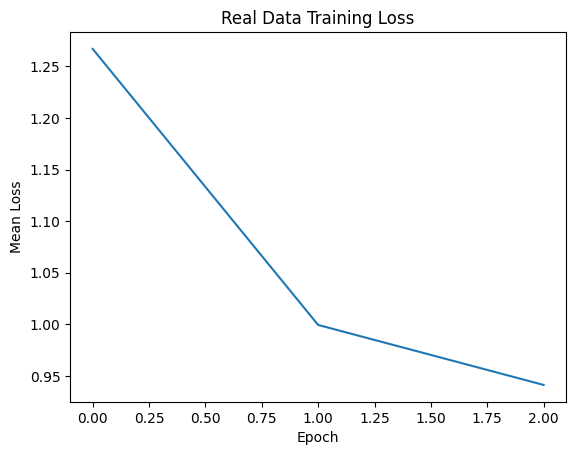

In [ ]:
# Training loop goes here
# Trains on real data with local candidate pools and CrossEntropyLoss.
# I put the learning rate at lr=0.0001 and added gradient clipping.
# I also put auto-checkpoint on google drive every 10k steps at each epoch
# in case Colab disconnects.
N_EPOCHS = 3
BATCH_LOG_EVERY = 5000
CHECKPOINT_EVERY = 10000

x_axis, y_axis = [], []

for epoch in range(N_EPOCHS):
    random.shuffle(train_examples)
    epoch_losses = []

    for step, (question_text, person_name, relation, answer_text) in enumerate(tqdm(train_examples)):
        q_vec, k_tensor, v_tensor, tgt_idx = example_to_tensors(
            question_text, person_name, relation, DB_filtered, train_people_list, VOCAB
        )
        if tgt_idx is None:
            continue

        q_vec = q_vec.to(device)
        k_tensor = k_tensor.to(device)
        v_tensor = v_tensor.to(device)
        target = torch.tensor(tgt_idx).to(device)

        optimizer.zero_grad()
        output = model(q_vec, k_tensor, v_tensor)
        v_embedded = model.B(v_tensor)
        logits = torch.inner(v_embedded, output)

        loss = criterion(logits.unsqueeze(0), target.unsqueeze(0))
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()

        epoch_losses.append(loss.item())

        if step % BATCH_LOG_EVERY == 0 and step > 0:
            recent_mean = sum(epoch_losses[-BATCH_LOG_EVERY:]) / len(epoch_losses[-BATCH_LOG_EVERY:])
            print(f"Epoch {epoch}, step {step}/{len(train_examples)}, recent mean loss {recent_mean:.4f}")

        if step % CHECKPOINT_EVERY == 0 and step > 0:
            torch.save({
                'model_state_dict': model.state_dict(),
                'epoch': epoch,
                'step': step,
            }, 'drive/MyDrive/kvmemnet_model_checkpoint.pt')


    mean_loss = sum(epoch_losses) / len(epoch_losses)
    x_axis.append(epoch)
    y_axis.append(mean_loss)
    print(f"=== Epoch {epoch} complete, mean loss {mean_loss:.4f} ===")

    torch.save({
        'model_state_dict': model.state_dict(),
        'epoch': epoch,
        'step': len(train_examples),
    }, 'drive/MyDrive/kvmemnet_model_checkpoint.pt')

plt.plot(x_axis, y_axis)
plt.xlabel("Epoch")
plt.ylabel("Mean Loss")
plt.title("Real Data Training Loss")
plt.show()

In [ ]:
# Save final trained model weights to Google drive
torch.save(model.state_dict(), 'drive/MyDrive/kvmemnet_model_final.pt')
print("Final model saved to Drive")

Final model saved to Drive


**Write the code for testing your model on the test data**

Your training loop can call the testing loop. But make sure that you do one last test on the model after training completes.

In [ ]:
# Testing loop goes here
correct = 0
total = 0

model.eval()  # switches to evaluation mode
with torch.no_grad():
    for question_text, person_name, relation, answer_text in tqdm(test_examples):
        q_vec, k_tensor, v_tensor, tgt_idx = example_to_tensors(
            question_text, person_name, relation, DB_filtered, train_people_list, VOCAB
        )
        if tgt_idx is None:
            continue

        q_vec = q_vec.to(device)
        k_tensor = k_tensor.to(device)
        v_tensor = v_tensor.to(device)

        output = model(q_vec, k_tensor, v_tensor)
        v_embedded = model.B(v_tensor)
        logits = torch.inner(v_embedded, output)
        pred = logits.argmax().item()

        correct += int(pred == tgt_idx)
        total += 1

accuracy = correct / total
print(f"Test Accuracy: {correct}/{total} = {accuracy:.2%}")
model.train()

100%|██████████| 19215/19215 [01:50<00:00, 174.34it/s]

Test Accuracy: 12369/19215 = 64.37%


KVMemNet(
  (A): Linear(in_features=29390, out_features=128, bias=False)
  (B): Linear(in_features=29390, out_features=128, bias=False)
)

**Suggestion:** Once you have a model that has decent accuracy, you may want to save it to your Google Drive using ``torch.save()`` and load it when working on the next part of the assignment using ``torch.load()``.

# Part E: Use the Model (5 points)

Given a question in natural language, turn it into a bag of words and feed it into the model with a set of plausible keys and values. Apply the output feature embedding to the full set of values and pick the value with argmax. Return the actual text inside that value (not the bag of words or embedding).

That is, given a natural language question, you are asked to create the $q$ and pick a relevant subset of $k$ and $v$. Run the $q$, $k$, and $v$ through the model and get an answer to the original question.

For example a question might be "When was Alexander Hamilton born?" Depending on how you pre-proessed your data, you may need to extract the entity and the relation.

Write a function that takes in the `question` below, the data, and the model, and outputs the text answer, e.g., "11 january 1755". You must use your ``KVMemNet``.

**Suggestion:** To process a question you will probably want to find the entity and the relation. You may use packages such as [NLTK](https://www.nltk.org/) (already imported), [SpaCY](https://spacy.io/), [Stanza](https://stanfordnlp.github.io/stanza/), or other.

Change the question to test your implementation, but don't delete this cell.

In [ ]:
question = "When was alexander hamilton born?"

**Create your function for using the `KVMemNet` to answer a given question.**

The function should take in the question, data, model, and any other parameters you need. The function should return a text string.

You can create as many cells as necessary. Save the notebook cells showing one example of your input question and output answer. For grading we will look to see that your question is in natural language, the model is used, and the answer is in text. The example doesn't have to be correct. You will analyze your technique later in the report.

In [ ]:
# Loading the model
model = KVMemNet(
    vocab_size=VOCAB.num_words(),
    embed_dim=128
).to(device)

model_path = "/content/drive/MyDrive/kvmemnet_model_final.pt"

model.load_state_dict(
    torch.load(model_path, map_location=device)
)

model.eval()

print("Trained model loaded successfully.")

Trained model loaded successfully.


In [ ]:
# Create your functions here
# This function answers the Natural Language question.
# extract_person_name finds the person via longest substring
# match. ask_question then checks over that specific
# person's key-value facts for an answer.
def extract_person_name(question_text, DB_filtered):
    q_lower = question_text.lower()
    best_match = None
    best_len = 0
    for name in DB_filtered.keys():
        if name in q_lower and len(name) > best_len:
            best_match = name
            best_len = len(name)
    return best_match


def ask_question(question_text, DB_filtered, vocab, model):
    person_name = extract_person_name(question_text, DB_filtered)
    if person_name is None:
        return "Sorry, I couldn't identify who this question is about."

    person_info = DB_filtered[person_name]
    keys_text = list(person_info.keys())
    values_text = list(person_info.values())

    q_vec = torch.tensor(safe_multihot(question_text, vocab), dtype=torch.float32).to(device)
    key_vecs = np.stack([safe_multihot(k, vocab) for k in keys_text])
    value_vecs = np.stack([safe_multihot(v, vocab) for v in values_text])
    keys_tensor = torch.tensor(key_vecs, dtype=torch.float32).to(device)
    values_tensor = torch.tensor(value_vecs, dtype=torch.float32).to(device)

    model.eval()
    with torch.no_grad():
        output = model(q_vec, keys_tensor, values_tensor)
        v_embedded = model.B(values_tensor)
        logits = torch.inner(v_embedded, output)
        pred_idx = logits.argmax().item()

    return values_text[pred_idx]


answer = ask_question(question, DB_filtered, VOCAB, model)
print(f"Question: {question}")
print(f"Answer: {answer}")

Question: When was alexander hamilton born?
Answer: 11 january 1755


In [ ]:
# More sample questions
test_questions = [
    "When was alexander hamilton born?",
    "What political party did alexander hamilton belong to?",
    "Where did alexander hamilton go to school?",
    "Who was alexander hamilton's spouse?",
]

for q in test_questions:
    answer = ask_question(q, DB_filtered, VOCAB, model)
    print(f"Q: {q}")
    print(f"A: {answer}")
    print()

Q: When was alexander hamilton born?
A: 11 january 1755

Q: What political party did alexander hamilton belong to?
A: federalist

Q: Where did alexander hamilton go to school?
A: kings college new york

Q: Who was alexander hamilton's spouse?
A: elizabeth schuyler



In [ ]:
# Getting some unseen people from test-set to form more questions
sample_test_people = list(test_people)[:3]
print(sample_test_people)

['alimardan topchubashov', 'mark eves', 'clarence w. allgood']


In [ ]:
#Building questions based on test-set names
more_questions = [
    f"What office did {sample_test_people[0]} hold?",
    f"When was {sample_test_people[1]} born?",
    f"Where was {sample_test_people[2]} born?",
    f"Where did {sample_test_people[2]} study?"

]

for q in more_questions:
    answer = ask_question(q, DB_filtered, VOCAB, model)
    print(f"Q: {q}")
    print(f"A: {answer}")
    print()

Q: What office did alimardan topchubashov hold?
A: deputy of the first state duma minister of foreign affairs of azerbaijan democratic republic adr head of the parliament in absentia of azerbaijan

Q: When was mark eves born?
A: 16 march 1977

Q: Where was clarence w. allgood born?
A: birmingham alabama

Q: Where did clarence w. allgood study?
A: alabama polytechnic institute b birmingham school of law ll



In [ ]:
# Some limitations found on the model
questions = [
    "On what day did alexander hamilton enter the world?",
    "What university awarded kelvin hopkins his degree?",
    "When was an unknown person born?",
    "When was Alex Hamilton born?"
]

for q in questions:
    print("Question:", q)
    print()
    print("Answer:", ask_question(q, DB_filtered, VOCAB, model))
    print("\n" * 5)

Question: On what day did alexander hamilton enter the world?

Answer: elizabeth schuyler






Question: What university awarded kelvin hopkins his degree?

Answer: member of parliament for luton north






Question: When was an unknown person born?

Answer: Sorry, I couldn't identify who this question is about.






Question: When was Alex Hamilton born?

Answer: Sorry, I couldn't identify who this question is about.








# Part F: Reporting (15 points)

Your report should answer the following three questions:

 **Q1:** What pre-processing of the data did you do? What motivated the design decisions and how did it impact training and any processing of natural language questions (Parts A and D)?

 Hint: This should help one understand any code modifications you made in Parts A and the first part of Part D. But you shouldn't use this to document your code (hopefully you commented your code with code comments and text cells above), but to justify your choices as well as to explain what worked and what didn't work.

 **Q2:** Report on your training on the real data (Part D). Show your loss curve and report on the testing accuracy. There are many ways to implement the training loop, particularly with the choice of keys and values. What decisions did you make when developing your training loop? Justify your decisions. How did they impact the training?

 Hint: This assignment doesn't grade you on how well your model learns---your solution will not be perfect. We focus more on how you worked through the process. This part of the report should show how well your solution worked, but also the intuition for why it works, and to document the things you tried that didn't work.

 **Q3:** Describe your technique on how you process natural language questions (Part E). Provide some examples of your technique answering questions correctly and some examples of your technique answering questions incorrectly. Discuss what causes the failure cases.

 Hint: You are not penalized for incorrectly answered questions---your model will not be perfect---we are looking for honest reflection. Preferably, show the example as code blocks running your model with notebook outputs saved.

 We have provided three prompts below. You can create as many text and code cells as necessary.

**Q1: Report on Data Pre-processing**

I used a custom 'make_db' function to parse the raw Wikipedia biography dataset into key-value attributes per person. I filtered the dataset with the 'office' key, which limits the dataset to politicians. This was a planned choice: it resulted in a much more consistent dataset (~40,786 people) with predictable relation types (birth_date, spouse, party, etc.), which significantly improved template-based question generation for Part D.

Initially, my vocabulary contained 96,093 unique words. Since the size of my embedding layer depends on 'vocab_size$\times$embed_dim', this resulted in unnecessary model increase. Due to this, I used the 'reduce_vocab' function with a minimum word occurrence of 5, which reduced the vocabulary to 29,390 words. This is because very rare words contribute little during training while increasing the embedding matrix greatly. It was close to a 70% reduction while preserving all reasonably common terms, enabling efficient model training without significantly affecting vocabulary coverage.

Instead of constructing questions by simple concatenation of entity name and relation (e.g., "alexander hamilton birth_date"), I introduced relation-specific manually designed questions (e.g. When was {name} born?"). I selected eight well-represented relations from the filtered dataset: birth_date, birth_place, office, party, spouse, death_date, occupation, alma_mater. Each of these relations was associated with one or two templates to provide variations in question generation. I made sure this approach aligned with Part E's natural language input, so that we didn't need to create a separate question translation step.

My vocabulary was solely built from the biography data (Part A). As a result, common question terms used in Part D (e.g., "what", "when", "who") were not present because they rarely appear in structured infobox data. My original 'multihot' function could not handle out-of-vocabulary words, causing a 'KeyError' for unseen words. I addressed this by writing a 'safe_multihot' function, which replaces unknown words with the existing 'UNK' token.

For every (person, relation) pair, I generated a single training example consisting of '(question_text, person_name, relation, answer_text)'. I performed a 90/10 train/test split to ensure individuals appeared in only one set. This prevented person-level data overlap between the train and test set, making the test accuracy a measure of true generalization instead of memorization of specific person's data.




**Q2: Report on Training and Testing**

I used 172,382 training examples and 19,215 testing examples for training on the biography data. The model had an embedding dimension of 128 with a vocabulary size of 29,390. I used the Adam optimizer to train it for three epochs with cross-entropy loss and a learning rate of 0.0001.



For every training example, I included all key-value pairs associated with the person in the question. As distractors, I included a small number of facts from three randomly selected people, and from each person, up to two facts were selected. I made this selection because the task would be too easy if I had selected the target person's facts only. The model might simply learn that all available facts are relevant to the person, instead of how the question's wording match to the correct relation. The distractor facts forced the model to attend more closely to relation-specific words such as "born", "spouse", "party", and "school".



I did not compare the model's output to every value in the full database. This is because embedding every possible answer at each training step with nearly 200,000 examples and unique values would have required significant memory and computation. Instead, I compared the output to the values included in the current memory set, and the target was the index of the value associated with the requested relation. As a result, the training became manageable while the model learned to select the correct value from a mixture of irrelevant and relevant facts.



I converted the question, keys, and values into multi-hot vectors. Embedding layer A processed the question and keys, while the values were passed through embedding layer B. Attention weights were calculated by using the similarity between the question and key embeddings. Finally, this output was compared with all value embeddings in the current example and applied cross-entropy loss to train the model toward the correct value.



Before each epoch, I shuffled the training examples so that the model would not repeatedly encounter people or relations in the same order. I also applied gradient clipping with a maximum norm of 1.0 to reduce the risk of overly large or unstable gradient updates. Since training on the full dataset required a significant amount of time, I saved checkpoints every 10,000 steps as well as at the end of each epoch.

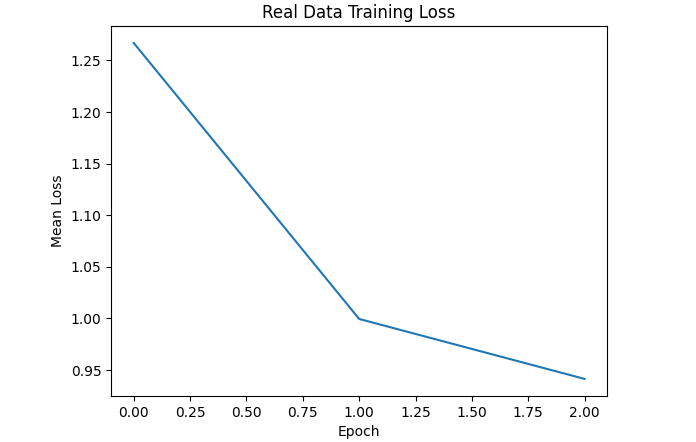

The loss curve indicated clear signs that the model was learning. During the beginning of the first epoch, the recent average loss was close to 2.16, but it gradually decreased as the training continued. The mean loss was about 1.2668 after the first epoch, 0.9995 after the second epoch, and after the final epoch, it was recorded to 0.9414. Compared to the synthetic dataset, the loss did not decrease smoothly because of the greater variation present in the real dataset. The number of facts per person varies, answer lengths differ greatly, and randomly chosen distractors shift the difficulty of individual examples. Despite the fluctuations, the general downward trend shows that the model learned meaningful relationships between natural-language questions and database keys.



The model correctly answered 12,369 out of 19,215 examples, resulting in a test accuracy of 64.37% on the non-overlapping test set. Since the data was divided by person into train and test sets, none of the test individuals were seen during training. As a result, this measures the model's ability to generalize relation-related question wording to unseen, new people, rather than its capacity to memorize specific biographies.



While the result is not perfect, it is reasonable for a single-hop memory network using multi-hot representations. The model lacks an understanding of grammar, context, or word order the way a more advanced language model would. It largely learns associations between words in the question and relation keys. Adding more question templates, pretrained word embeddings, or training for additional epochs could potentially improve the model's performance.


**Q3: Report on Model Use**

To process a natural-language question, I first determined which person is being asked about. I used the "extract_person_name" function that converts the question to lowercase and looks for the longest database name that appears within it. This approach helped to avoid selecting a shorter name in cases where one name is contained within another.



Once the person is identified, I retrieved all the relation-value pairs available for that person from the filtered database. I then converted the question, relation keys, and answer values into multi-hot vectors using the "safe_multihot" function. Any words missing from the vocabulary were mapped to the 'UNK' token instead of causing the program to crash.



Next, I passed the question vector and the selected key-value tensors through 'KVMemNet'. The network measured the similarity between question embeddings and key embeddings, and assigned attention to the relevant relations. The resulting output was then compared against the embedded values, and the value with the highest score was returned as the text answer.



This model correctly answered several questions in the notebook. For example:



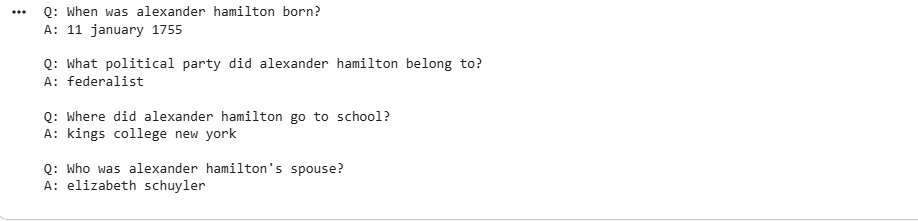





Additionally, the model correctly answered questions involving people from the test set, who were unseen during training:



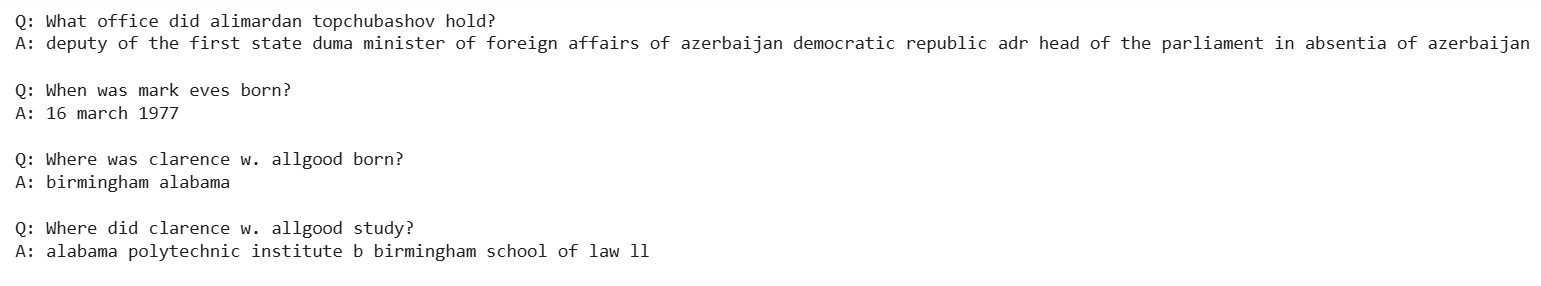


These examples indicate that the model learned meaningful relationships between relations and question expressions. For example, the model learned that "When was....born?" is associated with 'birth_date', that "What party....?" is associated with 'party', and that "Where did......study?" is related to 'alma_mater'.



That said, the model could produce incorrect answers when a question was phrased differently from the training templates. Let's take a look at this question below:


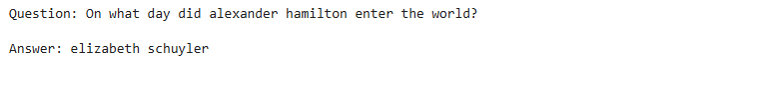



It failed to provide a correct answer because the phrase "enter the world" did not appear in the birth-date templates. In this case, the model focused on the person's name and mistakenly selected the spouse value 'Elizabeth Schuyler.



Another failure was:



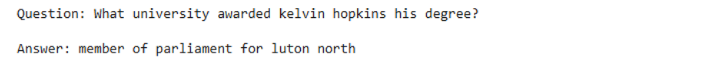



For 'alma_mater', the training questions relied mostly on wording such as "Where did....go to school?" and "What is the alma mater of .....?" Since words like "degree", "university", and "awarded" did not provide the same learned signal, the model failed to recognize the intended relation and mistakenly returned Kelvin Hopkin's office instead.



The model failed when it was asked about a person not present in the database:



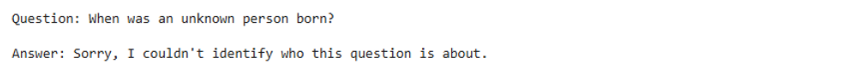



This happened before the neural network was even applied, since the person-extraction step requires an exact database-name match. Variations such as nicknames, misspellings, alternate forms of a person's name, or titles could lead to failure.



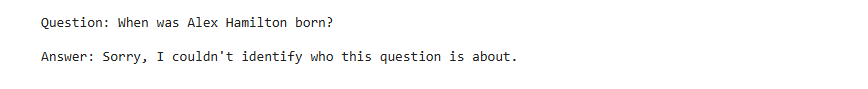

For example, using "Alex Hamilton" instead of "Alexander Hamilton" in a question would fail to identify the correct person.



Another limitation is that the model relied on a multi-hot bag-of-words representation. This representation captures word presence but disregards their order. Because of this, the model could not differentiate sentences based on sentence structure or grammar. Additionally, it gives equal weight to all recognized words, regardless of their usage or position in the sentence.



The model is also limited to single-hop questions, meaning it could answer direct questions related to a person's spouse or birthdate, but not the ones that require multiple reasoning steps. For instance, a question like "What is the capital of the country where Alexander Hamilton was born?" would require retrieving the birthplace, determining the country, and then identifying the country's capital.



Overall, this model performs best when the question includes the person's full database name and uses similar words that were used during the template training. The majority of the failures occur due to unknown words, unfamiliar wording, misspelled names, ambiguity between similar relations, or questions requiring reasoning beyond a single key-value matching.  
